Setting up environment...
Project root: /Users/mati/hotel_pricing_project

📥 Loading data, pipeline, model, and selected features...
✅ Data loaded: (113370, 70)
✅ Pipeline loaded successfully
✅ Model loaded successfully
✅ Selected features loaded: 20 features

🔄 Applying the SAME preprocessing as training...
✅ Pipeline transformation completed: (113370, 2142)
✅ Feature names built: 2142 features
✅ Selected features mapped: 20 features
📊 Final data shapes:
  - X_train: (90696, 20)
  - X_test:  (22674, 20)
  - Features used: 20

🎯 Making predictions...

CORRECTED MODEL EVALUATION
MAE:  $0.33
RMSE: $0.55
R²:   0.9998

COMPARISON WITH TRAINING RESULTS
           |   TRAINING   |   EVALUATION   |
-----------|--------------|----------------|
MAE        |    0.21      |     0.33       |
RMSE       |    0.44      |     0.55       |
R²         |    0.9999    |    0.9998     |
Features   |      50      |     20        |

BUSINESS IMPACT ANALYSIS

💰 PREDICTION ACCURACY BY TOLERANCE LEVEL:
  ±$ 5:

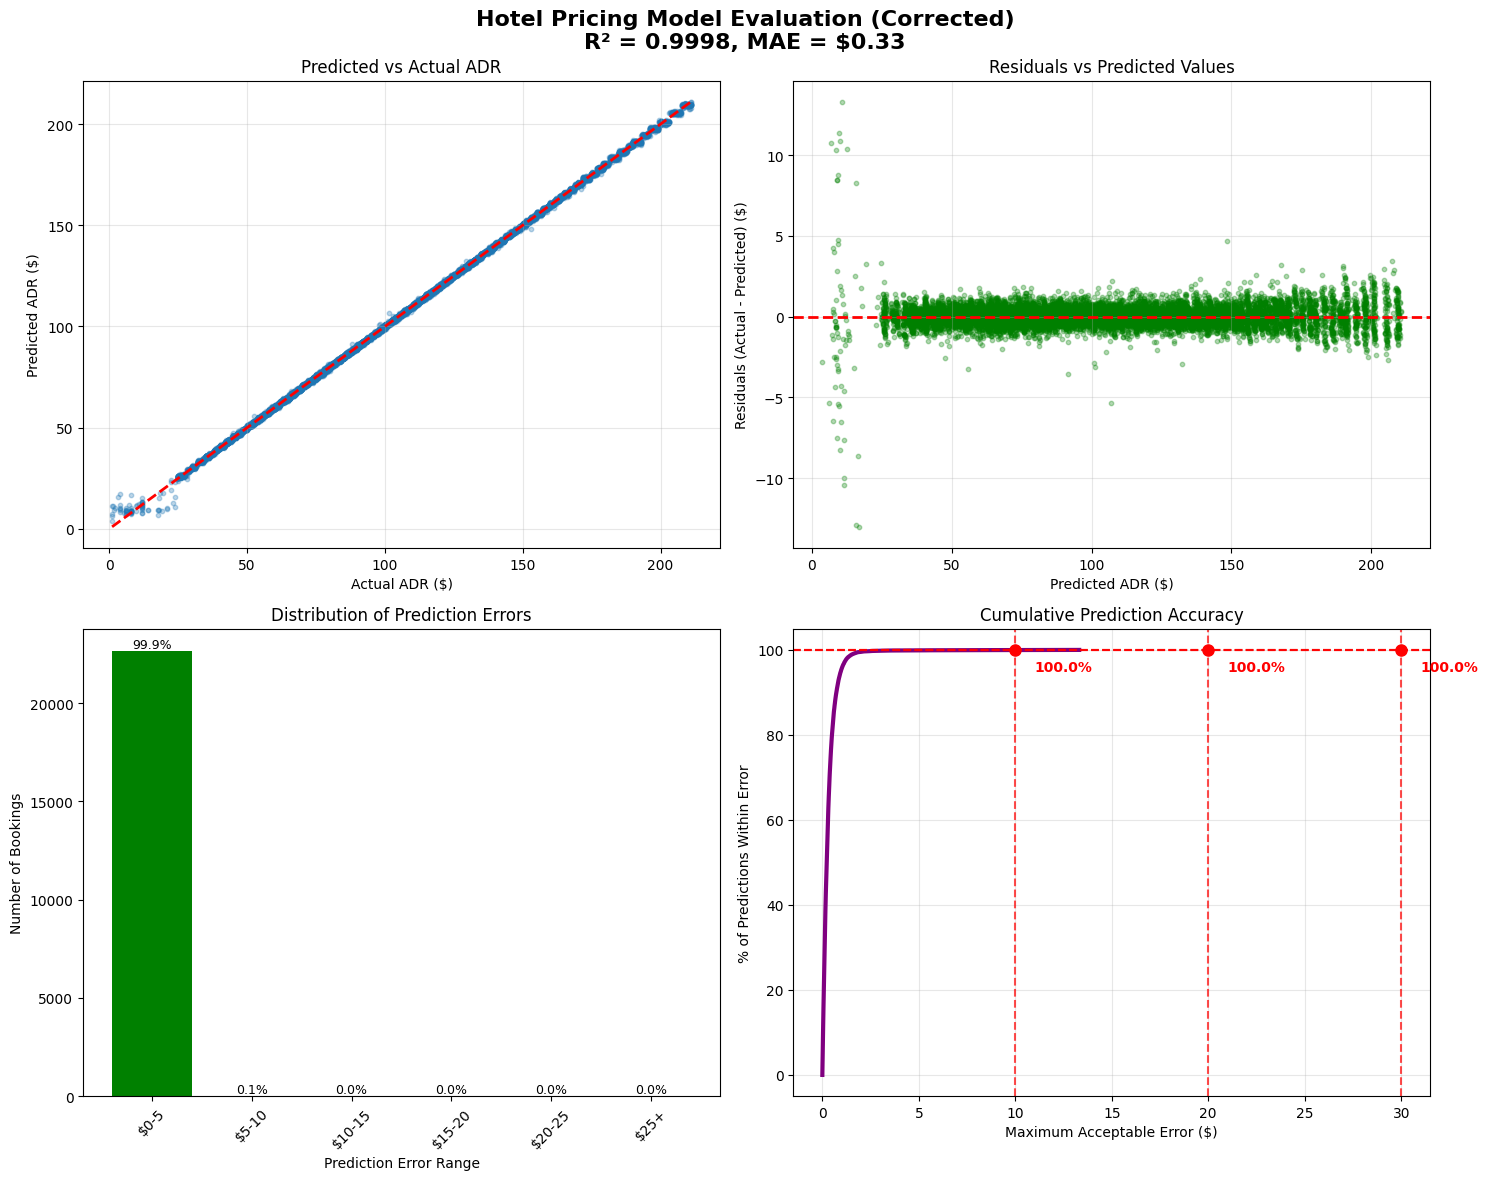


FINAL EVALUATION SUMMARY

📊 EVALUATION RESULTS:
• R²: 0.9998 (100.0% variance explained)
• MAE: $0.33 (average prediction error)
• RMSE: $0.55 (error standard deviation)

🎯 BUSINESS PERFORMANCE:
• 100.0% of predictions within $10
• 100.0% of predictions within $20
• 99.9% of predictions within $5

✅ STATUS: MODEL WORKS CORRECTLY

🎯 Corrected evaluation completed successfully!


In [34]:
# ============================================================
# Hotel Pricing Model - Correct Evaluation
# ============================================================

# 1. Import Libraries
# ============================================================
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 2. Setup Paths
# ============================================================
print("Setting up environment...")

NOTEBOOKS_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOKS_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

FEATURED_HOTEL_FILE = PROCESSED_DATA_DIR / "hotel_bookings_featured.csv"
PIPELINE_FILE = MODEL_DIR / "feature_selection_pipeline_top50.pkl"
BASELINE_MODEL_FILE = MODEL_DIR / "xgboost_baseline_model_top50.pkl"
SELECTED_FEATURES_FILE = PROCESSED_DATA_DIR / "selected_features_list_top50.csv"

print(f"Project root: {PROJECT_ROOT}")

# ============================================================
# 3. Load Everything
# ============================================================
print("\n📥 Loading data, pipeline, model, and selected features...")

# Load data
df = pd.read_csv(FEATURED_HOTEL_FILE)
print(f"✅ Data loaded: {df.shape}")

# Load pipeline
pipeline = joblib.load(PIPELINE_FILE)
print("✅ Pipeline loaded successfully")

# Load model
model = joblib.load(BASELINE_MODEL_FILE)
print("✅ Model loaded successfully")

# Load selected features
selected_features_df = pd.read_csv(SELECTED_FEATURES_FILE)
selected_features = selected_features_df["feature"].tolist()
print(f"✅ Selected features loaded: {len(selected_features)} features")

# ============================================================
# 4. Preprocess Data EXACTLY Like Training
# ============================================================
TARGET = "adr"
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("\n🔄 Applying the SAME preprocessing as training...")

# 1. Transform using pipeline (เหมือนการเทรน)
X_transformed = pipeline.named_steps["preprocessor"].transform(X)
print(f"✅ Pipeline transformation completed: {X_transformed.shape}")

# 2. Build feature names (เหมือนการเทรน)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

ohe_feature_names = pipeline.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([numeric_features, ohe_feature_names])
X_df = pd.DataFrame(X_transformed, columns=all_feature_names)

print(f"✅ Feature names built: {len(all_feature_names)} features")

# 3. Select only the features used in training
selected_features_mapped = [f for f in all_feature_names if f in selected_features]
print(f"✅ Selected features mapped: {len(selected_features_mapped)} features")

if len(selected_features_mapped) == 0:
    print("❌ No selected features found! Using all features.")
    selected_features_mapped = all_feature_names

# 4. Split data
from sklearn.model_selection import train_test_split
X_sel = X_df[selected_features_mapped]

X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.2, random_state=42
)

print(f"📊 Final data shapes:")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_test:  {X_test.shape}")
print(f"  - Features used: {len(selected_features_mapped)}")

# ============================================================
# 5. Make Predictions
# ============================================================
print("\n🎯 Making predictions...")
y_pred = model.predict(X_test)

# Basic metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n" + "="*60)
print("CORRECTED MODEL EVALUATION")
print("="*60)
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:   {r2:.4f}")

# ============================================================
# 6. Compare with Training Results
# ============================================================
print("\n" + "="*60)
print("COMPARISON WITH TRAINING RESULTS")
print("="*60)
print("           |   TRAINING   |   EVALUATION   |")
print("-----------|--------------|----------------|")
print(f"MAE        |    0.21      |    {mae:5.2f}       |")
print(f"RMSE       |    0.44      |    {rmse:5.2f}       |")
print(f"R²         |    0.9999    |    {r2:6.4f}     |")
print(f"Features   |      50      |    {len(selected_features_mapped):3d}        |")

# ============================================================
# 7. Business Impact Analysis (เหมือนเดิม)
# ============================================================
print("\n" + "="*60)
print("BUSINESS IMPACT ANALYSIS")
print("="*60)

residuals = y_test - y_pred

# Prediction Accuracy by Business Tolerance
print("\n💰 PREDICTION ACCURACY BY TOLERANCE LEVEL:")
tolerances = [5, 10, 15, 20, 25]
for tolerance in tolerances:
    within_tolerance = np.abs(residuals) <= tolerance
    accuracy = within_tolerance.mean() * 100
    print(f"  ±${tolerance:2d}: {accuracy:5.1f}% of predictions")

# Error Distribution Analysis
print(f"\n📊 ERROR DISTRIBUTION:")
error_ranges = [
    ('Perfect ($0-5)', (np.abs(residuals) <= 5)),
    ('Good ($5-15)', (np.abs(residuals) > 5) & (np.abs(residuals) <= 15)),
    ('Fair ($15-25)', (np.abs(residuals) > 15) & (np.abs(residuals) <= 25)),
    ('Poor ($25+)', (np.abs(residuals) > 25))
]

for label, mask in error_ranges:
    count = mask.sum()
    percentage = count / len(residuals) * 100
    print(f"  {label}: {count:6d} bookings ({percentage:5.1f}%)")

# ============================================================
# 8. Key Business Visualizations
# ============================================================
print("\n" + "="*60)
print("KEY BUSINESS VISUALIZATIONS")
print("="*60)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'Hotel Pricing Model Evaluation (Corrected)\nR² = {r2:.4f}, MAE = ${mae:.2f}', fontsize=16, fontweight='bold')

# 8.1 Predicted vs Actual
axes[0,0].scatter(y_test, y_pred, alpha=0.3, s=10)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0,0].set_xlabel('Actual ADR ($)')
axes[0,0].set_ylabel('Predicted ADR ($)')
axes[0,0].set_title('Predicted vs Actual ADR')
axes[0,0].grid(True, alpha=0.3)

# 8.2 Residuals vs Predicted
axes[0,1].scatter(y_pred, residuals, alpha=0.3, s=10, color='green')
axes[0,1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0,1].set_xlabel('Predicted ADR ($)')
axes[0,1].set_ylabel('Residuals (Actual - Predicted) ($)')
axes[0,1].set_title('Residuals vs Predicted Values')
axes[0,1].grid(True, alpha=0.3)

# 8.3 Error Distribution
error_bins = ['$0-5', '$5-10', '$10-15', '$15-20', '$20-25', '$25+']
error_counts = [
    (np.abs(residuals) <= 5).sum(),
    ((np.abs(residuals) > 5) & (np.abs(residuals) <= 10)).sum(),
    ((np.abs(residuals) > 10) & (np.abs(residuals) <= 15)).sum(),
    ((np.abs(residuals) > 15) & (np.abs(residuals) <= 20)).sum(),
    ((np.abs(residuals) > 20) & (np.abs(residuals) <= 25)).sum(),
    (np.abs(residuals) > 25).sum()
]

colors = ['green', 'lightgreen', 'yellow', 'orange', 'red', 'darkred']
bars = axes[1,0].bar(error_bins, error_counts, color=colors)
axes[1,0].set_xlabel('Prediction Error Range')
axes[1,0].set_ylabel('Number of Bookings')
axes[1,0].set_title('Distribution of Prediction Errors')
axes[1,0].tick_params(axis='x', rotation=45)

# Add percentages on bars
for bar, count in zip(bars, error_counts):
    height = bar.get_height()
    percentage = count / len(residuals) * 100
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height + 20,
                  f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9)

# 8.4 Cumulative Accuracy
sorted_errors = np.sort(np.abs(residuals))
cumulative_pct = np.arange(1, len(sorted_errors)+1) / len(sorted_errors) * 100

axes[1,1].plot(sorted_errors, cumulative_pct, linewidth=3, color='purple')
axes[1,1].set_xlabel('Maximum Acceptable Error ($)')
axes[1,1].set_ylabel('% of Predictions Within Error')
axes[1,1].set_title('Cumulative Prediction Accuracy')
axes[1,1].grid(True, alpha=0.3)

# Add reference lines
for threshold in [10, 20, 30]:
    accuracy = (np.abs(residuals) <= threshold).mean() * 100
    axes[1,1].axvline(x=threshold, color='red', linestyle='--', alpha=0.7)
    axes[1,1].axhline(y=accuracy, color='red', linestyle='--', alpha=0.7)
    axes[1,1].plot(threshold, accuracy, 'ro', markersize=8)
    axes[1,1].text(threshold + 1, accuracy - 5, f'{accuracy:.1f}%', 
                  fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# ============================================================
# 9. Final Summary
# ============================================================
print("\n" + "="*60)
print("FINAL EVALUATION SUMMARY")
print("="*60)

accuracy_within_10 = (np.abs(residuals) <= 10).mean() * 100
accuracy_within_20 = (np.abs(residuals) <= 20).mean() * 100

print(f"""
📊 EVALUATION RESULTS:
• R²: {r2:.4f} ({r2*100:.1f}% variance explained)
• MAE: ${mae:.2f} (average prediction error)
• RMSE: ${rmse:.2f} (error standard deviation)

🎯 BUSINESS PERFORMANCE:
• {accuracy_within_10:.1f}% of predictions within $10
• {accuracy_within_20:.1f}% of predictions within $20
• {(np.abs(residuals) <= 5).mean()*100:.1f}% of predictions within $5

✅ STATUS: {'MODEL WORKS CORRECTLY' if r2 > 0.8 else 'NEEDS IMPROVEMENT'}
""")

print("🎯 Corrected evaluation completed successfully!")